In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

### Retrieve T3Z1 PTOFamps and EventTime data

In [3]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [4]:
filepath = np.sort(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_????????_??????.root'))

In [5]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [6]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [7]:
RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime"])
df_rqs = df_filtered.AsNumpy(RQs)

### Define material properties and reference dates

In [8]:
import datetime

In [9]:
# Cf252 radioactive properties
Cf252_halflife = 8.341e7 # s
Cf252_lifetime = Cf252_halflife / np.log(2) # s
Cf252_lambda   = 1 / Cf252_lifetime # Hz

# Ge-71 radioactive properties
Ge71_halflife = 990835 # s
Ge71_lifetime = Ge71_halflife / np.log(2) # s
Ge71_lambda   = 1 / Ge71_lifetime

In [10]:
Cf252_activity = 37000                                                # activity of Cf252 at reference time; given in Hz
t_ref          = datetime.datetime(2020, 3, 15, 00, 0).timestamp()    # reference time of nominal activity; Unix time
activ_prob     = 9208e-9                                              # Ge activations per neutron emitted; found using sourcesim w/ CUTE geometry

# rate of Ge activation during exposure
A = Cf252_activity * activ_prob # activations / second

### Set up for integrating over activation and decay periods, read in and store time stamps of exposure periods

In [11]:
start_times = pd.read_csv('source_exposure_start_times.csv')
end_times = pd.read_csv('source_exposure_end_times.csv')

exposures = {i: {} for i in range(8)}

for i in range(8):
    year_0, year_f   = start_times['year'][i], end_times['year'][i]
    month_0, month_f = start_times['month'][i], end_times['month'][i]
    day_0, day_f     = start_times['day'][i], end_times['day'][i]
    hour_0, hour_f   = start_times['hour'][i], end_times['hour'][i]
    min_0, min_f     = start_times['minute'][i], end_times['minute'][i]
    s_0, s_f         = start_times['second'][i], end_times['second'][i]
    exposures[i]['t0'] = datetime.datetime(year_0, month_0, day_0, hour_0, min_0, s_0).timestamp()
    exposures[i]['tf'] = datetime.datetime(year_f, month_f, day_f, hour_f, min_f, s_f).timestamp()
    exposures[i]['dt'] = exposures[i]['tf'] - exposures[i]['t0']

In [12]:
# find total activations with N = int[ A exp( -lambda_Cf252 (t + t0) ) * exp(-lambda_Ge71 (T - t) ) ] dt + N0 exp(-lambda_Ge71 T) 
# t from t0 to T
def integrate_activations(N, T, t0):
    return (A / (Cf252_lambda - Ge71_lambda) * ( np.exp(- Cf252_lambda * t0 - Ge71_lambda * T) - np.exp(-Cf252_lambda * (T + t0)) ) + 
            N * np.exp(-Ge71_lambda * T) )

In [13]:
# data-taking window
datataking_start = datetime.datetime(2023, 12, 16, 0, 0, 0).timestamp()
datataking_end = datetime.datetime(2024, 1, 9, 0, 0, 0).timestamp()

### Plot exposure history (number of Ge-71 nuclei vs. time)

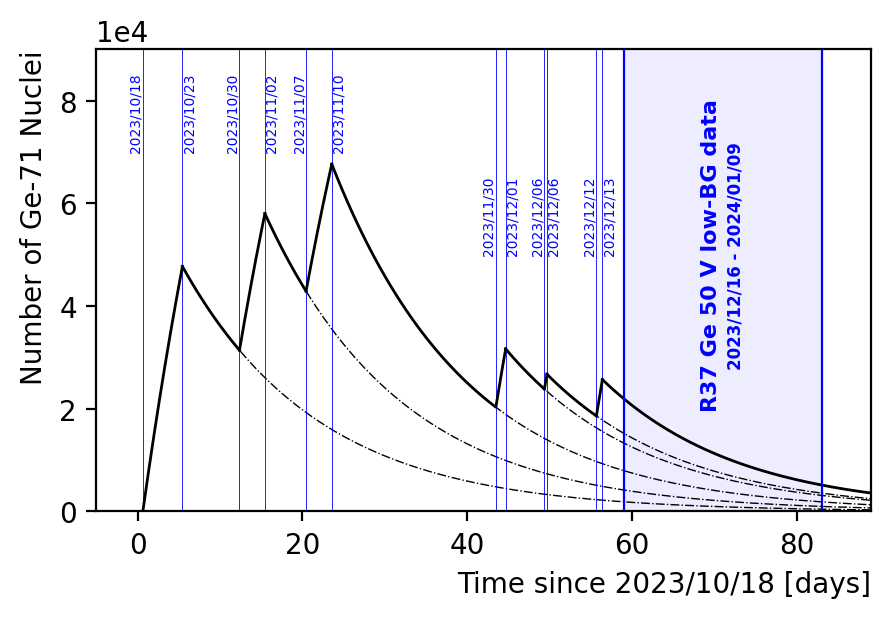

In [20]:
s2day = 1.157e-5
# time window for plotting
window_start = datetime.datetime(2023, 10, 18, 0, 0, 0).timestamp()
window_end = datetime.datetime(2024, 1, 10, 0, 0, 0).timestamp()

# initial number of activated Ge-71 nuclei
N = 0

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(exposures)):
    # Small exposure windows that clutter the plot. Exclude for plotting.
    if (i == 3) | (i == 4):
        continue
    # range of current exposure period
    t0      = exposures[i]['t0']
    tf      = exposures[i]['tf']
    
    # start of next exposure period (or end of window for plotting)
    t0_next = exposures[i+1]['t0'] if (i != len(exposures)-1) else window_end + 5/s2day
    
    # number of activated nuclei (N_activ) vs. time (t)
    t       = np.arange(t0, tf, 1)
    N_activ = integrate_activations(N, t - t0, t0 - t_ref)

    # vertical line and label at start and end of exposure window
    v_position = 7e4 if (i < 5) else 5e4
    start_text = datetime.datetime.fromtimestamp(t0).strftime("%Y/%m/%d")
    end_text = datetime.datetime.fromtimestamp(tf).strftime("%Y/%m/%d")
    plt.axvline((t0 - window_start)*s2day, 0, 1, lw = 0.3, color = 'blue')
    plt.axvline((tf - window_start)*s2day, 0, 1, lw = 0.3, color = 'blue')
    #plt.axvspan((t0 - window_start)*s2day, (tf - window_start)*s2day, alpha=0.03, color='blue', lw=0)
    plt.text((t0 - window_start)*s2day, v_position, start_text, rotation=90, fontsize = 5, ha='right', va='bottom', color = 'blue')
    plt.text((tf - window_start)*s2day, v_position, end_text, rotation=90, fontsize = 5, ha='left', va='bottom', color = 'blue')

    #### plot activations vs. time at start of window ####
    plt.plot((t - window_start)*s2day, N_activ, color = 'black', lw = 1)

    #### plot the decay of nuclei when not exposed to a source ####
    # need number of nuclei at end of exposure period (N0) and time range until next exposure period (delta_t)
    delta_t = np.linspace(0, t0_next - t[-1], 101)
    N0 = N_activ[-1]
    plt.plot((tf + delta_t - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t), color = 'black', lw = 1)
    # extrapolate to t -> inf
    delta_t_inf = np.linspace(0, t0_next*2 - t[-1], int(1e6))
    plt.plot((tf + delta_t_inf - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t_inf), color = 'black', lw = 0.5, ls = 'dashdot')
    # reset N (number of activated nuclei) for next exposure iteration
    N = N0 * np.exp(-Ge71_lambda * delta_t)[-1]

# indicate window of data-taking
start_text = datetime.datetime.fromtimestamp(datataking_start).strftime("%Y/%m/%d")
end_text = datetime.datetime.fromtimestamp(datataking_end).strftime("%Y/%m/%d")
plt.axvline((datataking_start - window_start)*s2day, 0, 1, lw = 0.8, color = 'blue')
plt.axvline((datataking_end - window_start)*s2day, 0, 1, lw = 0.8, color = 'blue')
plt.text((datataking_end - window_start)*s2day/2 + (datataking_start - window_start)*s2day/2 - 1.5, 5e4, 
        'R37 Ge 50 V low-BG data', rotation=90, fontsize = 8, ha='center', va='center', color = 'blue', fontweight='bold')
plt.text((datataking_end - window_start)*s2day/2 + (datataking_start - window_start)*s2day/2 + 1.5, 5e4, 
        start_text + ' - ' + end_text, rotation=90, fontsize = 6, ha='center', va='center', color = 'blue', fontweight='bold')
plt.axvspan((datataking_start - window_start)*s2day, (datataking_end - window_start)*s2day, alpha=0.07, color='blue', lw=0)


plt.ylim(0, 9e4)
plt.xlim(-5, (window_end - window_start) * s2day + 5)
plt.xlabel(f'Time since {datetime.datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [days]')
plt.ylabel('Number of Ge-71 Nuclei')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

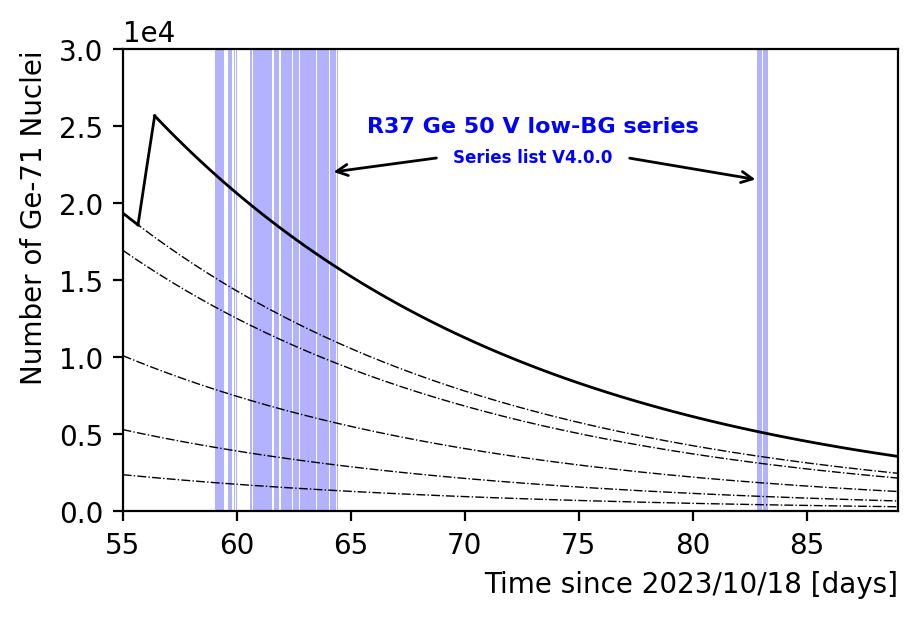

In [15]:
s2day = 1.157e-5
# time window for plotting
window_start = datetime.datetime(2023, 10, 18, 0, 0, 0).timestamp()
window_end = datetime.datetime(2024, 1, 10, 0, 0, 0).timestamp()

# initial number of activated Ge-71 nuclei
N = 0

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(exposures)):
    # Small exposure windows that clutter the plot. Exclude for plotting.
    if (i == 3) | (i == 4):
        continue
    # range of current exposure period
    t0      = exposures[i]['t0']
    tf      = exposures[i]['tf']
    
    # start of next exposure period (or end of window for plotting)
    t0_next = exposures[i+1]['t0'] if (i != len(exposures)-1) else window_end + 5/s2day
    
    # number of activated nuclei (N_activ) vs. time (t)
    t       = np.arange(t0, tf, 1)
    N_activ = integrate_activations(N, t - t0, t0 - t_ref)

    #### plot activations vs. time at start of window ####
    plt.plot((t - window_start)*s2day, N_activ, color = 'black', lw = 1)

    #### plot the decay of nuclei when not exposed to a source ####
    # need number of nuclei at end of exposure period (N0) and time range until next exposure period (delta_t)
    delta_t = np.linspace(0, t0_next - t[-1], 101)
    N0 = N_activ[-1]
    plt.plot((tf + delta_t - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t), color = 'black', lw = 1)
    # extrapolate to t -> inf
    delta_t_inf = np.linspace(0, t0_next*2 - t[-1], int(1e6))
    plt.plot((tf + delta_t_inf - window_start)*s2day, N0 * np.exp(-Ge71_lambda * delta_t_inf), color = 'black', lw = 0.5, ls = 'dashdot')
    # reset N (number of activated nuclei) for next exposure iteration
    N = N0 * np.exp(-Ge71_lambda * delta_t)[-1]

for sn in np.unique(df_rqs['SeriesNumber']):
    snCut = df_rqs['SeriesNumber'] == sn
    evtTimes = df_rqs['EventTime'][snCut]
    sn_start = min(evtTimes)
    sn_end = max(evtTimes)

    # vertical line and label at start and end of exposure window
    v_position = 3e4
    start_text = datetime.datetime.fromtimestamp(sn_start).strftime("%Y/%m/%d")
    end_text = datetime.datetime.fromtimestamp(sn_end).strftime("%Y/%m/%d")
    plt.axvspan((sn_start - window_start)*s2day, (sn_end - window_start)*s2day, alpha=0.3, color='blue', lw=0)

plt.text(73, 2.5e4, 'R37 Ge 50 V low-BG series', fontsize = 8, ha='center', va='center', color = 'blue', fontweight='bold')
plt.text(73, 2.3e4, 'Series list V4.0.0', fontsize = 6, ha='center', va='center', color = 'blue', fontweight='bold')
#plt.arrow(69, 2.3e4, -5, -0.1e4, color = 'blue', width = 0.1, head_width = 3, head_length = 3)
plt.annotate("", xytext=(69, 2.3e4), xy=(69-5, 2.3e4-0.1e4),
            arrowprops=dict(arrowstyle="->"), color = 'blue')
plt.annotate("", xytext=(77, 2.3e4), xy=(78+5, 2.3e4-0.15e4),
            arrowprops=dict(arrowstyle="->"), color = 'blue')
#arrow1 = mpatches.FancyArrow(69, 2.3e4, -5, -0.1e4,
                            #width=.1, length_includes_head=True, color="blue")
#plt.add_patch(arrow1)


plt.ylim(0, 3e4)
plt.xlim(55, (window_end - window_start) * s2day + 5)
plt.xlabel(f'Time since {datetime.datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [days]')
plt.ylabel('Number of Ge-71 Nuclei')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

In [16]:
#### starting with 0 nuclei activated ####
N = 0

#### track change in number of Ge-71 nuclei during and after exposures ####
for i in range(len(exposures)):
    N = integrate_activations(N, exposures[i]['dt'], exposures[i]['t0'] - t_ref)
    if (i != len(exposures) - 1):
        N = N * np.exp(-Ge71_lambda * (exposures[i+1]['t0'] - (exposures[i]['t0'] + exposures[i]['dt'])))
    else:
        # check change in number of Ge-71 during each series
        N_tot = 0
        for sn in np.unique(df_rqs['SeriesNumber']):
            snCut = df_rqs['SeriesNumber'] == sn
            evtTimes = df_rqs['EventTime'][snCut]
            sn_start = min(evtTimes)
            sn_end = max(evtTimes)

            N_start = N * np.exp(-Ge71_lambda * (sn_start - (exposures[len(exposures) - 1]['t0'] + exposures[len(exposures) - 1]['dt'])))
            N_end = N * np.exp(-Ge71_lambda * (sn_end - (exposures[len(exposures) - 1]['t0'] + exposures[len(exposures) - 1]['dt'])))
            print(f'{np.round(N_start - N_end)} Ge-71 events in series {int(sn)}')

            N_tot += N_start - N_end

print(f'{N_tot} total Ge-71 events')
print(f'{N_tot * 0.88} events in K shell peak')
print(f'{N_tot * 0.1} events in L shell peak')

153.0 Ge-71 events in series 23231216013604
278.0 Ge-71 events in series 23231216043946
32.0 Ge-71 events in series 23231216100125
144.0 Ge-71 events in series 23231216145300
48.0 Ge-71 events in series 23231216173436
55.0 Ge-71 events in series 23231216182937
13.0 Ge-71 events in series 23231216194929
59.0 Ge-71 events in series 23231216211119
18.0 Ge-71 events in series 23231216233807
141.0 Ge-71 events in series 23231217135018
185.0 Ge-71 events in series 23231217171613
242.0 Ge-71 events in series 23231217212512
316.0 Ge-71 events in series 23231218024511
201.0 Ge-71 events in series 23231218093255
146.0 Ge-71 events in series 23231218152721
77.0 Ge-71 events in series 23231218190035
235.0 Ge-71 events in series 23231218223530
324.0 Ge-71 events in series 23231219034952
300.0 Ge-71 events in series 23231219110331
289.0 Ge-71 events in series 23231219184002
169.0 Ge-71 events in series 23231220012745
281.0 Ge-71 events in series 23231220053358
276.0 Ge-71 events in series 2323122012